In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas
from scipy.optimize import bracket
from scipy.signal import find_peaks
import os

from Main_model.MRG_model.Sensory_axon.main_run import frequencies

# 1 ISI and membrane potential plots

In [2]:
def analyze_single_point(current_frequency, branch_point,time_trace, trace):
    bp = current_frequency[branch_point]
    bp_trace = list(bp.values())[trace][:]
    bp_peaks, _ = find_peaks(bp_trace, distance=50, height= -20)#np.max(bp_trace) - 10)
    bp_isi = np.diff(time_trace[bp_peaks])
    bp_times = (time_trace[bp_peaks[:-1]] + time_trace[bp_peaks[1:]]) / 2

    return bp_trace, bp_isi, bp_times, bp_peaks


In [9]:
filepath = r"C:\Users\User\PycharmProjects\peripheral_nerve_model\Data\sensory_axon\MRG_50_1000Hz_diam_5.7_amp_0.5.h5"

In [37]:
# Создаем папку для сохранения графиков
output_dir = "./../../../Data/sensory_axon/analysis_plots/"
os.makedirs(output_dir, exist_ok=True)

with h5py.File(filepath,'r') as f:
    print(f.keys())
    print(f["Frequency_1000Hz/Model"].keys())
    print(f["Frequency_1000Hz/Model/Traces"].keys())
    print(f["ModelParams"].attrs.keys())
    print(f["ModelParams"].attrs["dt_ms"])
    print(f["ModelParams"].attrs["h_stop"])
    print(f["ModelParams"].attrs["branch_nodes"])
    stim_params = f[f"Frequency_1000Hz/Stimulator"].attrs
    amp_nA = stim_params.get('amp')
    print(f"[START] processing {amp_nA} nA")

    time_trace = f["Frequency_1000Hz/Model/time"][:]

    frequencies = ['Frequency_050Hz', 'Frequency_100Hz', 'Frequency_150Hz', 'Frequency_200Hz', 'Frequency_250Hz', 'Frequency_300Hz', 'Frequency_350Hz', 'Frequency_400Hz', 'Frequency_450Hz', 'Frequency_500Hz', 'Frequency_550Hz', 'Frequency_600Hz', 'Frequency_650Hz', 'Frequency_700Hz', 'Frequency_750Hz', 'Frequency_800Hz', 'Frequency_850Hz', 'Frequency_900Hz', 'Frequency_950Hz', 'Frequency_1000Hz']

    '''
    i = 0
    while i != 1000:
        i += 50
        frequencies.append(f"Frequency_{i}Hz")

    print(frequencies)
    '''

    for freq in frequencies:
        #print(freq)
        current_frequency = f[f"{freq}/Model/Traces"]
        # Получаем параметры стимуляции
        stim_params = f[f"{freq}/Stimulator"].attrs
        amp_nA = stim_params.get('amp')
        print(current_frequency.keys())

        abd = (list(f[f"{freq}/Model/Traces/after_branch_daughter"].keys()))
        print(abd.sort())

        abm = f[f"{freq}/Model/Traces/after_branch_main/"]
        bb = f[f"{freq}/Model/Traces/before_branch/"]
        bp = f[f"{freq}/Model/Traces/branch_point/"]

        break

        '''
        #height = np.max(abd_trace) - 10
        sp_trace, sp_isi, sp_times, sp_peaks = analyze_single_point(current_frequency, "stimulation_point" ,time_trace, 0)
        for trace in range(4):
            print(f"Ветвление: {trace}, частота: {freq}")
            bp_trace, bp_isi, bp_times, bp_peaks = analyze_single_point(current_frequency, "branch_point" ,time_trace, trace)
            abd_trace, abd_isi, abd_times, abd_peaks = analyze_single_point(current_frequency, "after_branch_daughter",time_trace, trace)
            bb_trace, bb_isi, bb_times, bb_peaks = analyze_single_point(current_frequency, "before_branch" ,time_trace, trace)
            abm_trace, abm_isi, abm_times, abm_peaks = analyze_single_point(current_frequency, "after_branch_main" ,time_trace, trace)

            if time_trace[-1] >= 2000:
                start_idx = np.where(time_trace >= 2000)[0][0]
                if time_trace[-1] >= 2500:
                    end_idx = np.where(time_trace <= 2500)[0][-1]
                else:
                    end_idx = len(time_trace) - 1
            else:
                # Если 2000 мс нет в данных, используем последние 500 мс
                start_idx = max(0, len(time_trace) - 500)
                end_idx = len(time_trace) - 1

            # Создаем фигуру с 6 графиками (3 строки, 2 колонки)
            fig, axes = plt.subplots(3, 2, figsize=(16, 12))

            # Заголовок для всех графиков
            main_title = f"Частота: {freq}, Амплитуда: {amp_nA} нА, Ветвление: {trace}"
            fig.suptitle(main_title, fontsize=16, fontweight='bold', y=1.02)

            # Цвета для графиков
            colors = {
                'before_branch': 'blue',
                'after_branch_main': 'red',
                'after_branch_daughter': 'green'
            }

            # График 1,1: До ветвления (2000-2500 мс)
            ax = axes[0, 0]
            time_segment = time_trace[start_idx:end_idx]
            trace_segment = bb_trace[start_idx:end_idx]
            ax.plot(time_segment, trace_segment, linewidth=1.5, color=colors['before_branch'])

            # Фильтруем пики, которые попадают в выбранный диапазон
            bb_peaks_segment = [p for p in bb_trace if start_idx <= p < end_idx]
            if len(bb_peaks_segment) > 0:
                ax.scatter(time_trace[bb_peaks_segment], bb_trace[bb_peaks_segment],
                          s=80, color='black', zorder=5, label='Пики')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("Потенциал (мВ)")
            ax.set_title("До ветвления")
            ax.grid(True, alpha=0.3)
            ax.legend()

            # График 2,1: После ветвления - материнский аксон
            ax = axes[1, 0]
            trace_segment = abm_trace[start_idx:end_idx]
            ax.plot(time_segment, trace_segment, linewidth=1.5, color=colors['after_branch_main'])

            # Фильтруем пики, которые попадают в выбранный диапазон
            abm_peaks_segment = [p for p in abm_peaks if start_idx <= p < end_idx]
            if len(abm_peaks_segment) > 0:
                ax.scatter(time_trace[abm_peaks_segment], abm_trace[abm_peaks_segment],
                          s=80, color='black', zorder=5, label='Пики')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("Потенциал (мВ)")
            ax.set_title("После ветвления - материнский аксон")
            ax.grid(True, alpha=0.3)
            ax.legend()

            # График 3,1: После ветвления - дочерняя ветвь
            ax = axes[2, 0]
            trace_segment = abd_trace[start_idx:end_idx]
            ax.plot(time_segment, trace_segment, linewidth=1.5, color=colors['after_branch_daughter'])

            # Фильтруем пики, которые попадают в выбранный диапазон
            abd_peaks_segment = [p for p in abd_peaks if start_idx <= p < end_idx]
            if len(abd_peaks_segment) > 0:
                ax.scatter(time_trace[abd_peaks_segment], abd_trace[abd_peaks_segment],
                          s=80, color='black', zorder=5, label='Пики')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("Потенциал (мВ)")
            ax.set_title("После ветвления - дочерняя ветвь")
            ax.grid(True, alpha=0.3)
            ax.legend()

            # График 1,2: ISI vs Time
            ax = axes[0, 1]

            if len(bb_isi) > 0:
                ax.scatter(bb_times, bb_isi, s=40, alpha=0.7, color=colors['before_branch'], label='До ветвления')
            if len(abm_isi) > 0:
                ax.scatter(abm_times, abm_isi, s=40, alpha=0.7, color=colors['after_branch_main'], label='После (материнский)')
            if len(abd_isi) > 0:
                ax.scatter(abd_times, abd_isi, s=40, alpha=0.7, color=colors['after_branch_daughter'], label='После (дочерняя)')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("ISI (мс)")
            ax.set_title("Интервалы между спайками (ISI) vs Время")
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)

            # График 2,2: ISI_n vs ISI_{n+1}
            ax = axes[1, 1]

            if len(bb_isi) > 1:
                ax.scatter(bb_isi[:-1], bb_isi[1:], s=40, alpha=0.7, color=colors['before_branch'], label='До ветвления')
            if len(abm_isi) > 1:
                ax.scatter(abm_isi[:-1], abm_isi[1:], s=40, alpha=0.7, color=colors['after_branch_main'], label='После (материнский)')
            if len(abd_isi) > 1:
                ax.scatter(abd_isi[:-1], abd_isi[1:], s=40, alpha=0.7, color=colors['after_branch_daughter'], label='После (дочерняя)')

            # Добавляем линию y=x
            max_isi = max(
                np.max(bb_isi) if len(bb_isi) > 0 else 0,
                np.max(abm_isi) if len(abm_isi) > 0 else 0,
                np.max(abd_isi) if len(abd_isi) > 0 else 0
            )
            if max_isi > 0:
                ax.plot([0, max_isi], [0, max_isi], 'k--', alpha=0.5, label='y = x')

            ax.set_xlabel("ISI_n (мс)")
            ax.set_ylabel("ISI_{n+1} (мс)")
            ax.set_title("Карта возврата: ISI_n vs ISI_n+1")
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.axis('equal')

            # График 3,2: Гистограмма ISI
            ax = axes[2, 1]

            bins = 30
            all_isi = []
            if len(bb_isi) > 0:
                ax.hist(bb_isi, bins=bins, alpha=0.5, color=colors['before_branch'], label='До ветвления', density=True)
                all_isi.extend(bb_isi)
            if len(abm_isi) > 0:
                ax.hist(abm_isi, bins=bins, alpha=0.5, color=colors['after_branch_main'], label='После (материнский)', density=True)
                all_isi.extend(abm_isi)
            if len(abd_isi) > 0:
                ax.hist(abd_isi, bins=bins, alpha=0.5, color=colors['after_branch_daughter'], label='После (дочерняя)', density=True)
                all_isi.extend(abd_isi)

            ax.set_xlabel("ISI (мс)")
            ax.set_ylabel("Плотность вероятности")
            ax.set_title("Гистограмма интервалов между спайками")
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)

            # Настраиваем layout
            plt.tight_layout()

            # Сохраняем график в файл
            save_filename = f"{freq}_branch_{trace}.png"
            save_path = os.path.join(output_dir, save_filename)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close(fig)  # Закрываем фигуру для экономии памяти

            print(f"    График сохранен: {save_path}")
        '''

<KeysViewHDF5 ['Frequency_050Hz', 'Frequency_1000Hz', 'Frequency_100Hz', 'Frequency_150Hz', 'Frequency_200Hz', 'Frequency_250Hz', 'Frequency_300Hz', 'Frequency_350Hz', 'Frequency_400Hz', 'Frequency_450Hz', 'Frequency_500Hz', 'Frequency_550Hz', 'Frequency_600Hz', 'Frequency_650Hz', 'Frequency_700Hz', 'Frequency_750Hz', 'Frequency_800Hz', 'Frequency_850Hz', 'Frequency_900Hz', 'Frequency_950Hz', 'ModelParams']>
<KeysViewHDF5 ['Traces', 'time']>
<KeysViewHDF5 ['after_branch_daughter', 'after_branch_main', 'before_branch', 'branch_point', 'stimulation_point']>
<KeysViewHDF5 ['branch_nodes', 'branches_num', 'celsius', 'diam_scale', 'dt_ms', 'fiber_diameter_um', 'h_stop', 'nodes_dist', 'parent_axon_nodes']>
0.005
5100.0
5
[START] processing 0.5 nA
<KeysViewHDF5 ['after_branch_daughter', 'after_branch_main', 'before_branch', 'branch_point', 'stimulation_point']>
None


In [ ]:
print(np.mean(abm_trace))
print(np.max(abm_trace) - 10)

In [ ]:
peaks, _ = find_peaks(abm_trace, distance=50, height=np.max(abm_trace) - 10)
plt.figure(figsize=(20,10))
plt.plot(abm_trace)
plt.plot(peaks, abm_trace[peaks], "x")
#plt.xlim(0,10000)


In [ ]:
print(len(peaks))
print(peaks)
np.diff(peaks * dt_ms)

In [ ]:
print(len(abm_trace))

In [ ]:
print(len(time_trace) * 0.05 // 2)

In [ ]:
5010 // 0.005

In [ ]:
200401 * 0.005

In [ ]:
with h5py.File(filepath, 'r') as f:
    # Создаем папку для сохранения графиков
    output_dir = "./../../../Data/analysis_plots/"
    os.makedirs(output_dir, exist_ok=True)

    # Проходим по всем частотам (кроме ModelParams)
    for freq_name in f.keys():
        if freq_name == "ModelParams":
            continue

        print(f"\n{'='*60}")
        print(f"Анализ частоты: {freq_name}")
        print(f"{'='*60}")

        # Получаем временную ось
        time_trace = f[f"{freq_name}/Model/time"][:]

        # Получаем параметры стимуляции
        stim_params = f[f"{freq_name}/Stimulator"].attrs
        freq_hz = stim_params.get('frequency_hz', 50)
        amp_nA = stim_params.get('amp', 1.0)

        # Получаем группу с трассами
        traces_group = f[f"{freq_name}/Model/Traces"]

        # Определяем количество ветвлений (берем минимальное количество трасс среди всех групп)
        min_traces = float('inf')
        for group_name in traces_group.keys():
            group = traces_group[group_name]
            num_datasets = len(list(group.values()))
            min_traces = min(min_traces, num_datasets)

        print(f"Количество доступных ветвлений: {min_traces}")

        # Проходим по всем ветвлениям
        for trace_idx in range(min_traces):
            print(f"\n  Анализ ветвления {trace_idx}...")

            # Загружаем трассы для текущего ветвления
            try:
                before_branch = traces_group["before_branch"]
                after_branch_main = traces_group["after_branch_main"]
                after_branch_daughter = traces_group["after_branch_daughter"]

                bb_trace = list(before_branch.values())[trace_idx][:]
                abm_trace = list(after_branch_main.values())[trace_idx][:]
                abd_trace = list(after_branch_daughter.values())[trace_idx][:]

            except (KeyError, IndexError) as e:
                print(f"    Пропускаем ветвление {trace_idx}: {e}")
                continue

            # Находим индексы для временного диапазона 2000-2500 мс
            # Если временной диапазон меньше, используем доступный
            if time_trace[-1] >= 0:
                start_idx = np.where(time_trace >= 2000)[0][0]
                if time_trace[-1] >= 500:
                    end_idx = np.where(time_trace <= 2500)[0][-1]
                else:
                    end_idx = len(time_trace) - 1
            else:
                # Если 2000 мс нет в данных, используем последние 500 мс
                start_idx = max(0, len(time_trace) - 500)
                end_idx = len(time_trace) - 1

            # Создаем фигуру с 6 графиками (3 строки, 2 колонки)
            fig, axes = plt.subplots(3, 2, figsize=(16, 12))

            # Заголовок для всех графиков
            main_title = f"Частота: {freq_hz} Гц, Амплитуда: {amp_nA} нА, Ветвление: {trace_idx}"
            fig.suptitle(main_title, fontsize=16, fontweight='bold', y=1.02)

            # Цвета для графиков
            colors = {
                'before_branch': 'blue',
                'after_branch_main': 'red',
                'after_branch_daughter': 'green'
            }

            # График 1,1: До ветвления (2000-2500 мс)
            ax = axes[0, 0]
            time_segment = time_trace[start_idx:end_idx]
            trace_segment = bb_trace[start_idx:end_idx]
            ax.plot(time_segment, trace_segment, linewidth=1.5, color=colors['before_branch'])

            # Находим пики в полном диапазоне
            bb_peaks_full, _ = find_peaks(bb_trace, distance=50, height=np.max(bb_trace) - 10)
            # Фильтруем пики, которые попадают в выбранный диапазон
            bb_peaks_segment = [p for p in bb_peaks_full if start_idx <= p < end_idx]
            if len(bb_peaks_segment) > 0:
                ax.scatter(time_trace[bb_peaks_segment], bb_trace[bb_peaks_segment],
                          s=80, color='black', zorder=5, label='Пики')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("Потенциал (мВ)")
            ax.set_title("До ветвления")
            ax.grid(True, alpha=0.3)
            ax.legend()

            # График 2,1: После ветвления - материнский аксон
            ax = axes[1, 0]
            trace_segment = abm_trace[start_idx:end_idx]
            ax.plot(time_segment, trace_segment, linewidth=1.5, color=colors['after_branch_main'])

            # Находим пики в полном диапазоне
            abm_peaks_full, _ = find_peaks(abm_trace, distance=50, height=np.max(abm_trace) - 10)
            # Фильтруем пики, которые попадают в выбранный диапазон
            abm_peaks_segment = [p for p in abm_peaks_full if start_idx <= p < end_idx]
            if len(abm_peaks_segment) > 0:
                ax.scatter(time_trace[abm_peaks_segment], abm_trace[abm_peaks_segment],
                          s=80, color='black', zorder=5, label='Пики')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("Потенциал (мВ)")
            ax.set_title("После ветвления - материнский аксон")
            ax.grid(True, alpha=0.3)
            ax.legend()

            # График 3,1: После ветвления - дочерняя ветвь
            ax = axes[2, 0]
            trace_segment = abd_trace[start_idx:end_idx]
            ax.plot(time_segment, trace_segment, linewidth=1.5, color=colors['after_branch_daughter'])

            # Находим пики в полном диапазоне
            abd_peaks_full, _ = find_peaks(abd_trace, distance=50, height=np.max(abd_trace) - 10)
            # Фильтруем пики, которые попадают в выбранный диапазон
            abd_peaks_segment = [p for p in abd_peaks_full if start_idx <= p < end_idx]
            if len(abd_peaks_segment) > 0:
                ax.scatter(time_trace[abd_peaks_segment], abd_trace[abd_peaks_segment],
                          s=80, color='black', zorder=5, label='Пики')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("Потенциал (мВ)")
            ax.set_title("После ветвления - дочерняя ветвь")
            ax.grid(True, alpha=0.3)
            ax.legend()

            # Для графиков ISI используем пики из полного диапазона
            # Вычисляем ISI для каждой трассы
            def calculate_isi(peaks, time_array):
                if len(peaks) > 1:
                    isi = np.diff(time_array[peaks])
                    times = (time_array[peaks[:-1]] + time_array[peaks[1:]]) / 2
                    return isi, times
                return np.array([]), np.array([])

            # Вычисляем ISI для всех трасс
            bb_isi, bb_times = calculate_isi(bb_peaks_full, time_trace)
            abm_isi, abm_times = calculate_isi(abm_peaks_full, time_trace)
            abd_isi, abd_times = calculate_isi(abd_peaks_full, time_trace)

            # График 1,2: ISI vs Time
            ax = axes[0, 1]

            if len(bb_isi) > 0:
                ax.scatter(bb_times, bb_isi, s=40, alpha=0.7, color=colors['before_branch'], label='До ветвления')
            if len(abm_isi) > 0:
                ax.scatter(abm_times, abm_isi, s=40, alpha=0.7, color=colors['after_branch_main'], label='После (материнский)')
            if len(abd_isi) > 0:
                ax.scatter(abd_times, abd_isi, s=40, alpha=0.7, color=colors['after_branch_daughter'], label='После (дочерняя)')

            ax.set_xlabel("Время (мс)")
            ax.set_ylabel("ISI (мс)")
            ax.set_title("Интервалы между спайками (ISI) vs Время")
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)

            # График 2,2: ISI_n vs ISI_{n+1}
            ax = axes[1, 1]

            if len(bb_isi) > 1:
                ax.scatter(bb_isi[:-1], bb_isi[1:], s=40, alpha=0.7, color=colors['before_branch'], label='До ветвления')
            if len(abm_isi) > 1:
                ax.scatter(abm_isi[:-1], abm_isi[1:], s=40, alpha=0.7, color=colors['after_branch_main'], label='После (материнский)')
            if len(abd_isi) > 1:
                ax.scatter(abd_isi[:-1], abd_isi[1:], s=40, alpha=0.7, color=colors['after_branch_daughter'], label='После (дочерняя)')

            # Добавляем линию y=x
            max_isi = max(
                np.max(bb_isi) if len(bb_isi) > 0 else 0,
                np.max(abm_isi) if len(abm_isi) > 0 else 0,
                np.max(abd_isi) if len(abd_isi) > 0 else 0
            )
            if max_isi > 0:
                ax.plot([0, max_isi], [0, max_isi], 'k--', alpha=0.5, label='y = x')

            ax.set_xlabel("ISI_n (мс)")
            ax.set_ylabel("ISI_{n+1} (мс)")
            ax.set_title("Карта возврата: ISI_n vs ISI_{n+1}")
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.axis('equal')

            # График 3,2: Гистограмма ISI
            ax = axes[2, 1]

            bins = 30
            all_isi = []
            if len(bb_isi) > 0:
                ax.hist(bb_isi, bins=bins, alpha=0.5, color=colors['before_branch'], label='До ветвления', density=True)
                all_isi.extend(bb_isi)
            if len(abm_isi) > 0:
                ax.hist(abm_isi, bins=bins, alpha=0.5, color=colors['after_branch_main'], label='После (материнский)', density=True)
                all_isi.extend(abm_isi)
            if len(abd_isi) > 0:
                ax.hist(abd_isi, bins=bins, alpha=0.5, color=colors['after_branch_daughter'], label='После (дочерняя)', density=True)
                all_isi.extend(abd_isi)

            ax.set_xlabel("ISI (мс)")
            ax.set_ylabel("Плотность вероятности")
            ax.set_title("Гистограмма интервалов между спайками")
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)

            # Настраиваем layout
            plt.tight_layout()

            # Сохраняем график в файл
            save_filename = f"{freq_name}_branch_{trace_idx}.png"
            save_path = os.path.join(output_dir, save_filename)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close(fig)  # Закрываем фигуру для экономии памяти

            print(f"    График сохранен: {save_path}")

            # Выводим краткую статистику
            if len(all_isi) > 0:
                print(f"    Всего интервалов ISI: {len(all_isi)}")
                print(f"    Средний ISI: {np.mean(all_isi):.2f} мс")
                print(f"    Минимальный ISI: {np.min(all_isi):.2f} мс")
                print(f"    Максимальный ISI: {np.max(all_isi):.2f} мс")

    print(f"\n{'='*60}")
    print(f"Анализ завершен! Все графики сохранены в: {output_dir}")
    print(f"{'='*60}")

C:\Users\User\AppData\Local\Temp\ipykernel_23148\1194907702.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


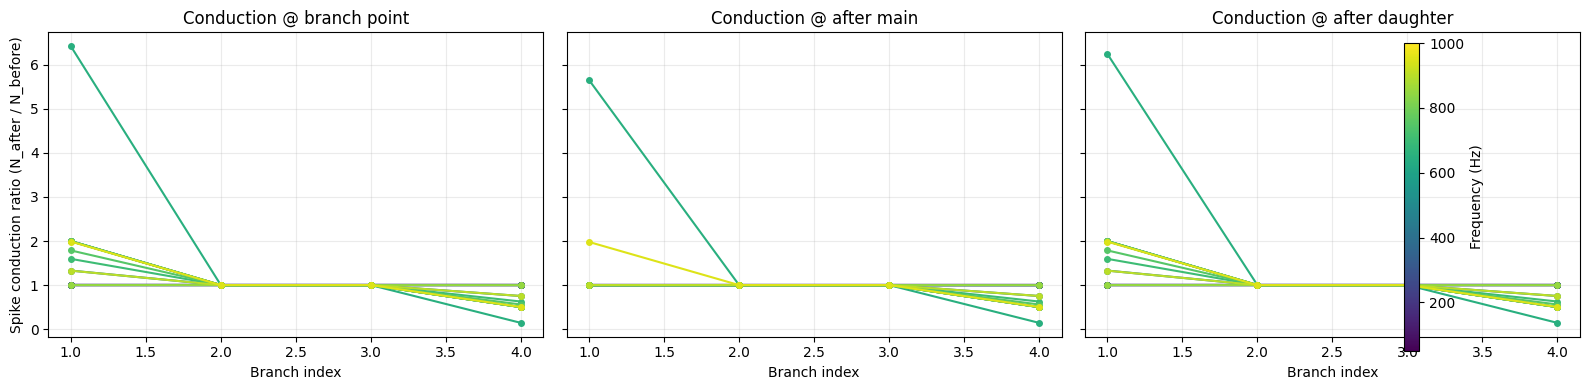

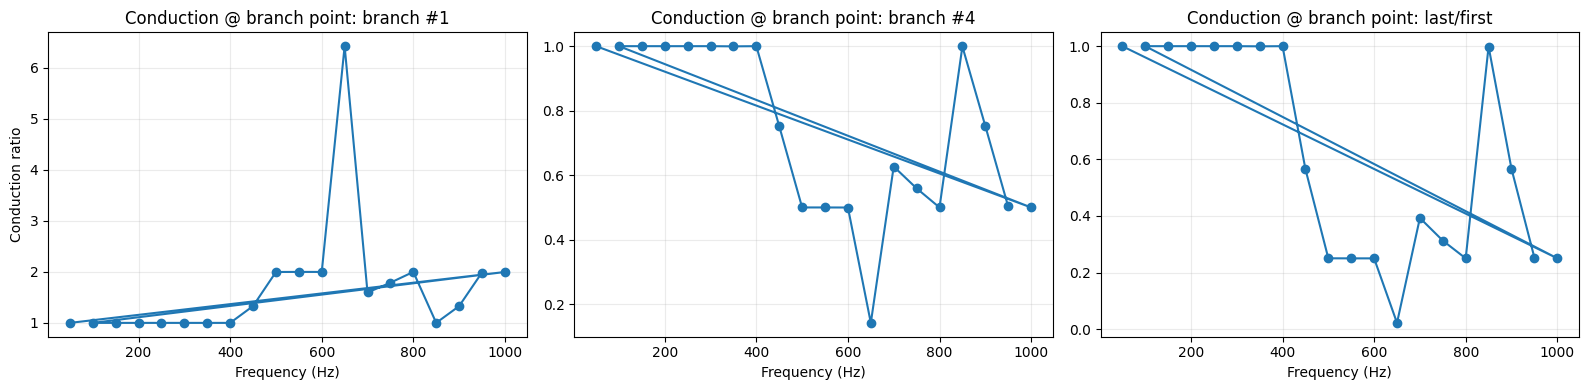

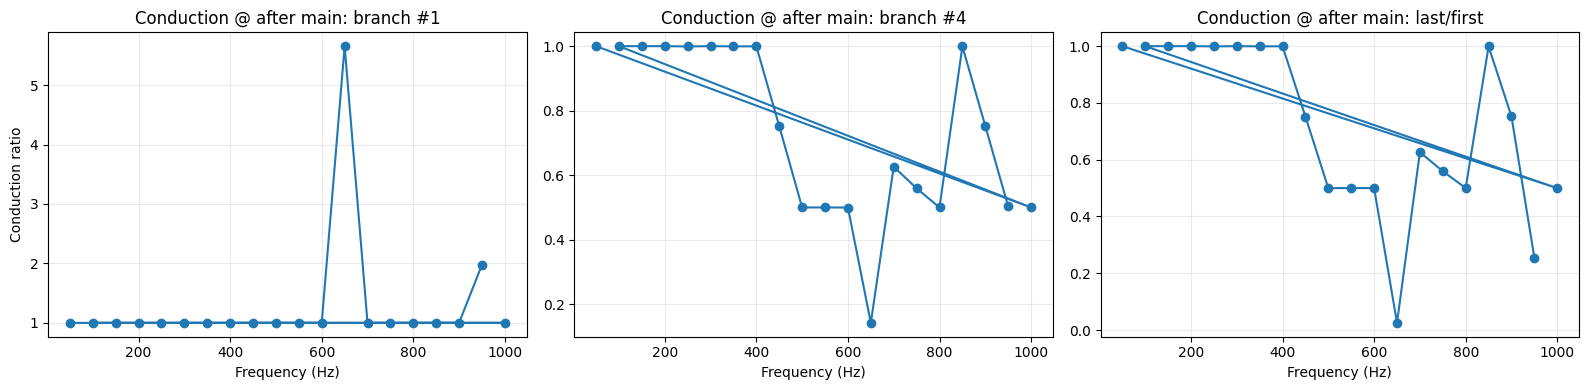

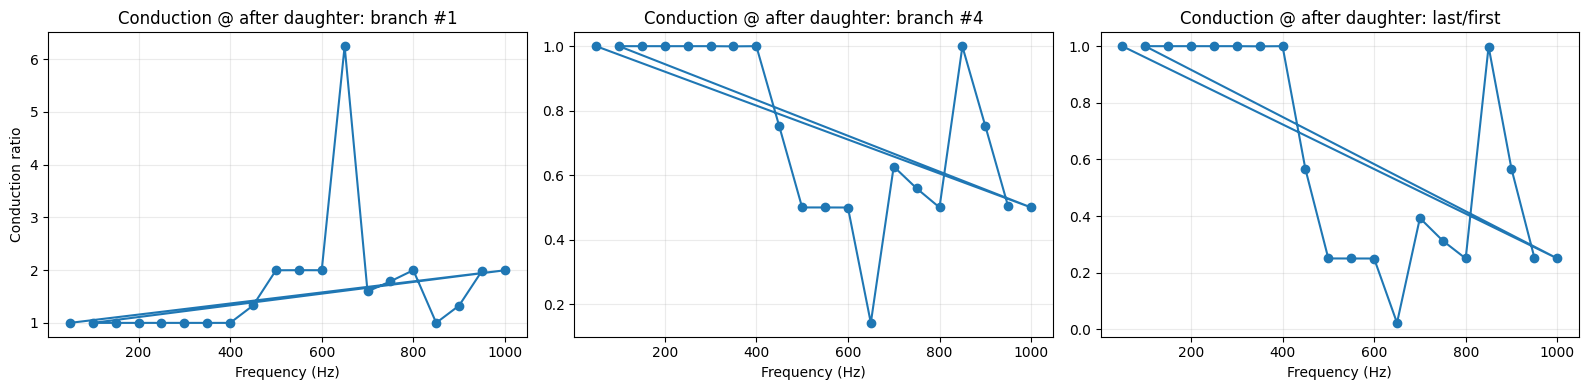

C:\Users\User\AppData\Local\Temp\ipykernel_23148\1194907702.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


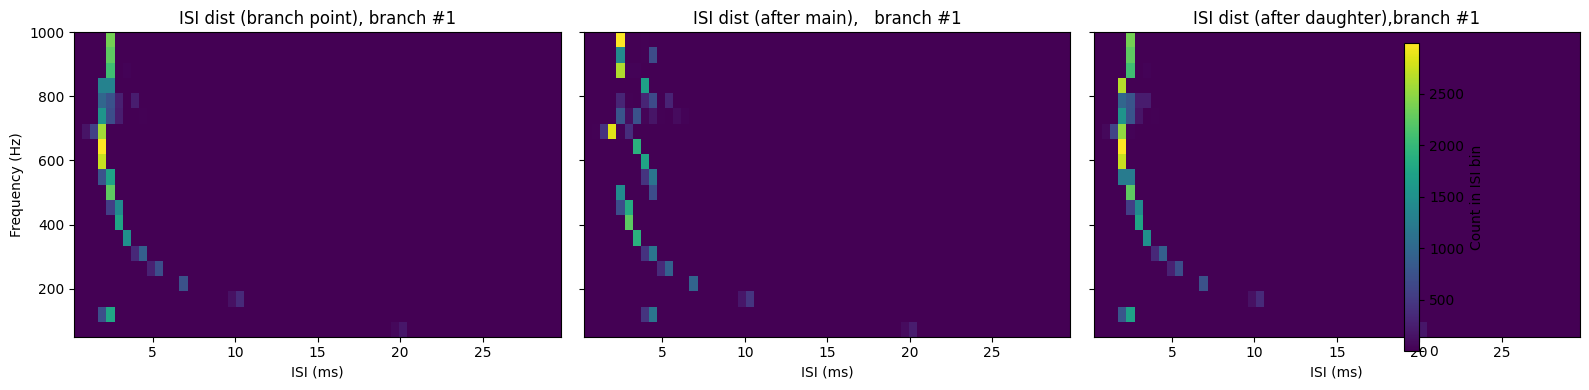

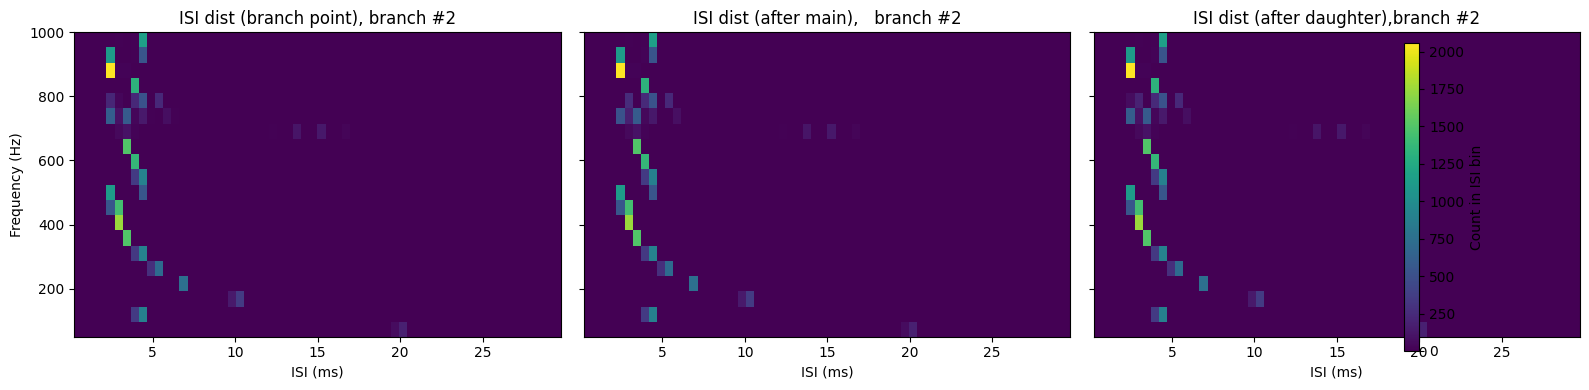

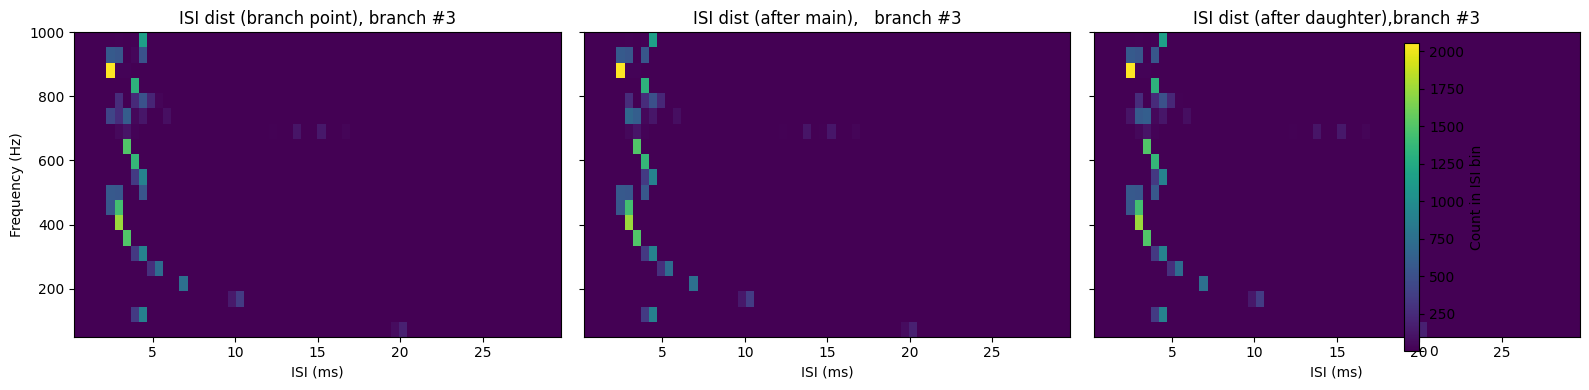

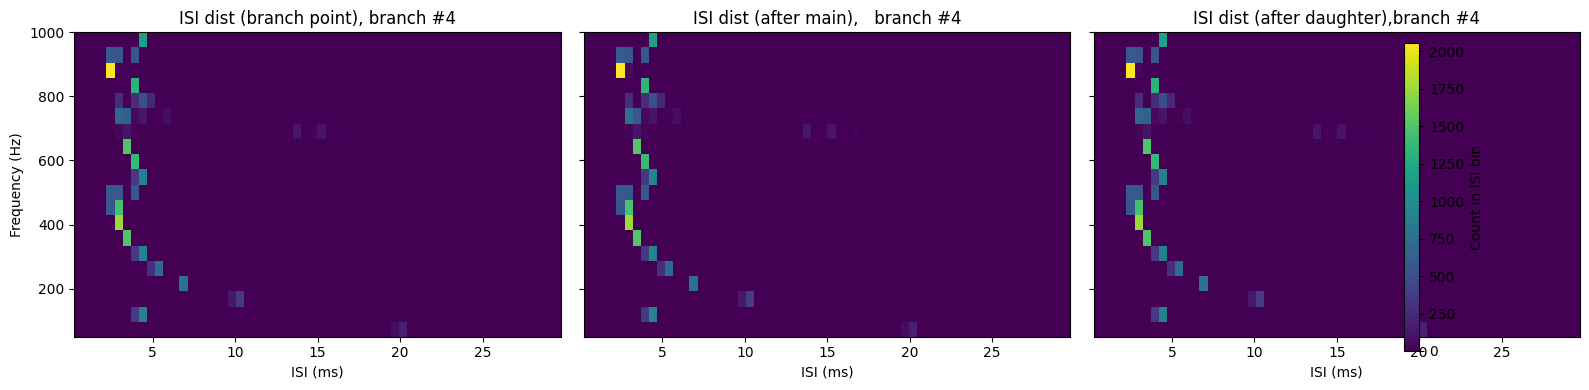

In [49]:
import h5py, numpy as np, matplotlib.pyplot as plt
from scipy.signal import find_peaks

filepath = r"C:\Users\User\PycharmProjects\peripheral_nerve_model\Data\MRG_MultiFreq_Stim_50_1000Hz_amp_2.h5"

# ---------------- helpers (короткие) ----------------
def peak_times(t, x, dt_ms, height=None):
    # distance: чтобы не ловить "двойные" пики внутри одного ПД при шуме/дрожании
    dist = max(1, int(0.5 / dt_ms))  # 0.5 ms
    if height is None:
        # адаптивный порог: верхние ~10% амплитуд
        height = np.quantile(x, 0.90)
    p, _ = find_peaks(x, height=height, distance=dist)
    return t[p]

def nspikes(t, x, dt_ms, height=None):
    return len(peak_times(t, x, dt_ms, height))

def isi_ms(t, x, dt_ms, height=None):
    pt = peak_times(t, x, dt_ms, height)
    return np.diff(pt) if len(pt) >= 2 else np.array([])

# ---------------- read all freqs ----------------
with h5py.File(filepath, "r") as f:
    # частоты = группы вида Frequency_050Hz ...
    freq_groups = sorted([k for k in f.keys() if k.startswith("Frequency_")])
    freqs = np.array([int(g.split("_")[1].replace("Hz","")) for g in freq_groups])

    dt_ms = float(f["ModelParams"].attrs.get("dt_ms", f["ModelParams"].attrs.get("dt", 0.005)))
    # время лучше брать внутри каждой частоты (на случай разных tstop), но обычно одинаковое
    t = f[f"{freq_groups[0]}/Model/time"][:]

    n_branches = len(f[f"{freq_groups[0]}/Model/Traces/before_branch"].keys())

    # массивы: [freq, branch]
    C_branch = np.full((len(freqs), n_branches), np.nan)
    C_main   = np.full((len(freqs), n_branches), np.nan)
    C_daugh  = np.full((len(freqs), n_branches), np.nan)

    # для ISI heatmap: соберём ISI для каждой частоты и ветвления (по каждой зоне)
    ISI_branch = [[None]*n_branches for _ in freqs]
    ISI_main   = [[None]*n_branches for _ in freqs]
    ISI_daugh  = [[None]*n_branches for _ in freqs]

    for fi, g in enumerate(freq_groups):
        tr = f[f"{g}/Model/Traces"]

        # возьмём базовый порог по before_branch(0) — чтобы одинаково детектить во всех точках
        x0 = tr["before_branch"][list(tr["before_branch"].keys())[0]][:]
        base_height = np.quantile(x0, 0.90)

        for bi in range(n_branches):
            # гарантируем одинаковый порядок: keys() может быть неотсортирован
            bb_key = sorted(tr["before_branch"].keys())[bi]
            bp_key = sorted(tr["branch_point"].keys())[bi]
            am_key = sorted(tr["after_branch_main"].keys())[bi]
            ad_key = sorted(tr["after_branch_daughter"].keys())[bi]

            bb = tr["before_branch"][bb_key][:]
            bp = tr["branch_point"][bp_key][:]
            am = tr["after_branch_main"][am_key][:]
            ad = tr["after_branch_daughter"][ad_key][:]

            n_bb = nspikes(t, bb, dt_ms, base_height)
            n_bp = nspikes(t, bp, dt_ms, base_height)
            n_am = nspikes(t, am, dt_ms, base_height)
            n_ad = nspikes(t, ad, dt_ms, base_height)

            # проводимость = доля спайков после/в точке относительно до
            if n_bb > 0:
                C_branch[fi, bi] = n_bp / n_bb
                C_main[fi, bi]   = n_am / n_bb
                C_daugh[fi, bi]  = n_ad / n_bb

            ISI_branch[fi][bi] = isi_ms(t, bp, dt_ms, base_height)
            ISI_main[fi][bi]   = isi_ms(t, am, dt_ms, base_height)
            ISI_daugh[fi][bi]  = isi_ms(t, ad, dt_ms, base_height)

# ---------------- 1) 3 графика в ряд: conduction vs branch point, цвет=частота ----------------
import matplotlib.cm as cm
cmap = cm.viridis
norm = plt.Normalize(vmin=freqs.min(), vmax=freqs.max())

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
x = np.arange(1, n_branches+1)

for fi, fr in enumerate(freqs):
    col = cmap(norm(fr))
    axs[0].plot(x, C_branch[fi], "-o", color=col, lw=1.5, ms=4)
    axs[1].plot(x, C_main[fi],   "-o", color=col, lw=1.5, ms=4)
    axs[2].plot(x, C_daugh[fi],  "-o", color=col, lw=1.5, ms=4)

axs[0].set_title("Conduction @ branch point")
axs[1].set_title("Conduction @ after main")
axs[2].set_title("Conduction @ after daughter")
for ax in axs:
    ax.set_xlabel("Branch index")
    ax.grid(alpha=0.25)
axs[0].set_ylabel("Spike conduction ratio (N_after / N_before)")

# фикс твоей ошибки colorbar: НУЖНО указать ax=...
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axs, label="Frequency (Hz)", fraction=0.025, pad=0.02)

plt.tight_layout()
plt.show()

# ---------------- 2) Сравнение 1-я vs последняя точка ветвления: 3 графика ----------------
# Для каждой зоны: (a) first vs freq, (b) last vs freq, (c) last/first vs freq
def first_last_plots(C, title):
    first = C[:, 0]
    last  = C[:, -1]
    ratio = last / first

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(freqs, first, "-o"); ax[0].set_title(f"{title}: branch #1")
    ax[1].plot(freqs, last,  "-o"); ax[1].set_title(f"{title}: branch #{n_branches}")
    ax[2].plot(freqs, ratio, "-o"); ax[2].set_title(f"{title}: last/first")
    for a in ax:
        a.set_xlabel("Frequency (Hz)")
        a.grid(alpha=0.25)
    ax[0].set_ylabel("Conduction ratio")
    plt.tight_layout()
    plt.show()

first_last_plots(C_branch, "Conduction @ branch point")
first_last_plots(C_main,   "Conduction @ after main")
first_last_plots(C_daugh,  "Conduction @ after daughter")

# ---------------- 3) ISI “гистограммы” как heatmap: 3 штуки на КАЖДОЕ ветвление ----------------
# (если хочешь только для одного ветвления — поставь например only_bi = 0 и убери цикл)
bins = np.linspace(0, 30, 61)  # 0..30 ms, шаг 0.5 ms (подстрой)
centers = 0.5*(bins[:-1] + bins[1:])

for bi in range(n_branches):
    # соберём матрицы [freq, bin]
    H_bp = np.zeros((len(freqs), len(centers)))
    H_am = np.zeros((len(freqs), len(centers)))
    H_ad = np.zeros((len(freqs), len(centers)))

    for fi in range(len(freqs)):
        for H, ISIs in [(H_bp, ISI_branch), (H_am, ISI_main), (H_ad, ISI_daugh)]:
            data = ISIs[fi][bi]
            if data is None or len(data) == 0:
                continue
            h, _ = np.histogram(data, bins=bins)
            H[fi] = h

    fig, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    im0 = ax[0].imshow(H_bp, aspect="auto", origin="lower",
                       extent=[centers.min(), centers.max(), freqs.min(), freqs.max()])
    im1 = ax[1].imshow(H_am, aspect="auto", origin="lower",
                       extent=[centers.min(), centers.max(), freqs.min(), freqs.max()])
    im2 = ax[2].imshow(H_ad, aspect="auto", origin="lower",
                       extent=[centers.min(), centers.max(), freqs.min(), freqs.max()])

    ax[0].set_title(f"ISI dist (branch point), branch #{bi+1}")
    ax[1].set_title(f"ISI dist (after main),   branch #{bi+1}")
    ax[2].set_title(f"ISI dist (after daughter),branch #{bi+1}")
    for a in ax:
        a.set_xlabel("ISI (ms)")
        a.grid(False)
    ax[0].set_ylabel("Frequency (Hz)")

    # один colorbar на всю фигуру
    fig.colorbar(im2, ax=ax, label="Count in ISI bin", fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()


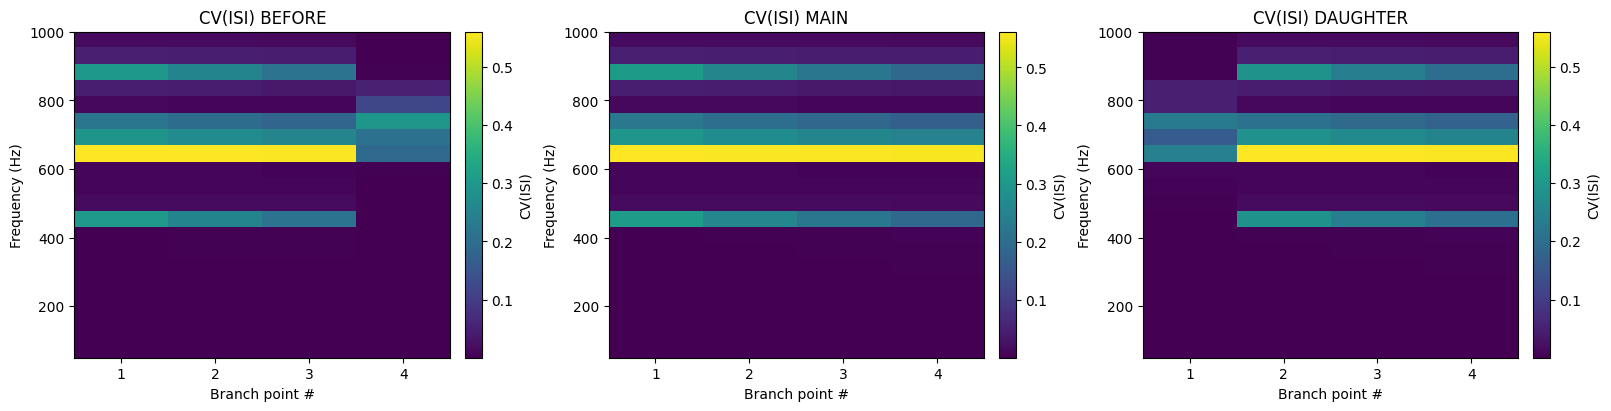

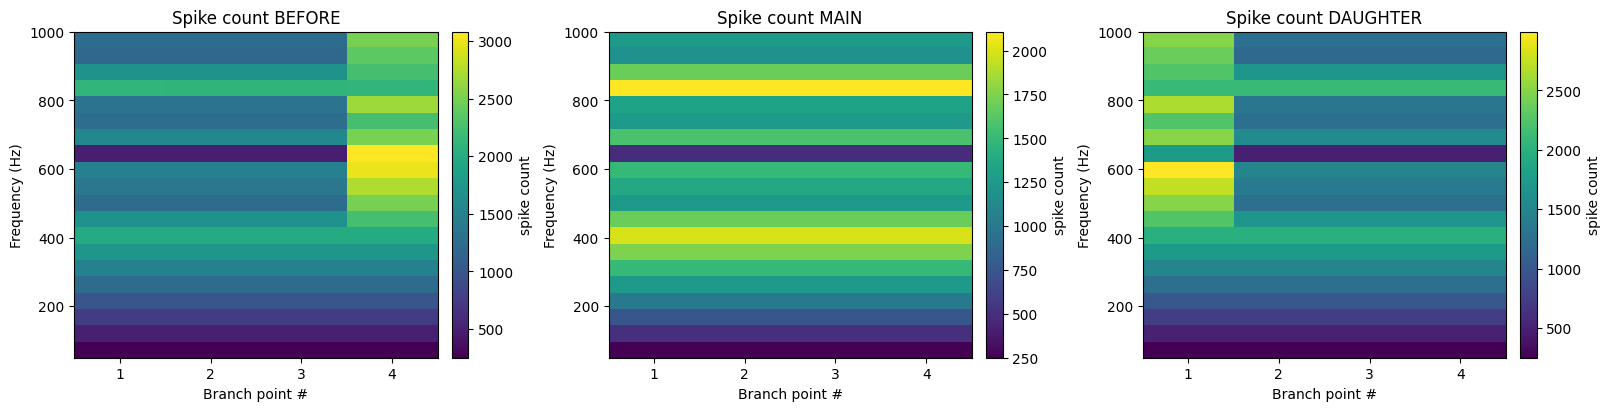

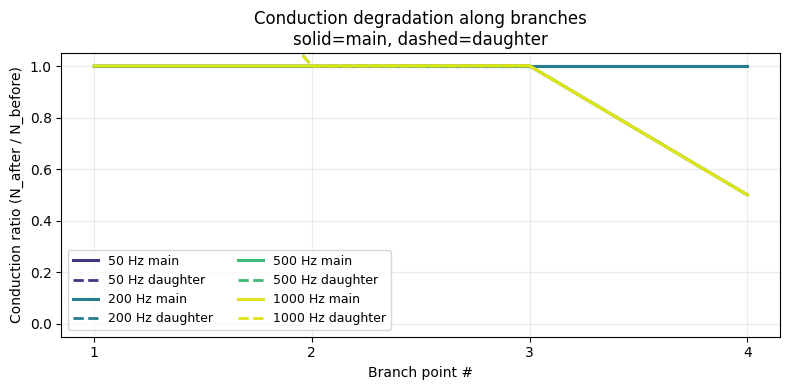

In [47]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

filepath = r"C:\Users\User\PycharmProjects\peripheral_nerve_model\Data\MRG_MultiFreq_Stim_50_1000Hz_amp_2.h5"

# ----------------------------
# load + collect metrics
# ----------------------------
with h5py.File(filepath, "r") as f:
    freq_keys = sorted([k for k in f.keys() if k.startswith("Frequency_")],
                       key=lambda s: int(s.split("_")[1].replace("Hz", "")))
    freqs = np.array([int(k.split("_")[1].replace("Hz", "")) for k in freq_keys], dtype=int)

    dt_ms = float(f["ModelParams"].attrs.get("dt_ms", 0.005))
    t = f[f"{freq_keys[0]}/Model/time"][:]

    bgrp0 = f[f"{freq_keys[0]}/Model/Traces/branch_point"]
    B = len(sorted(list(bgrp0.keys())))
    branches = np.arange(1, B + 1)

    N_before = np.zeros((len(freqs), B), dtype=int)
    N_main   = np.zeros((len(freqs), B), dtype=int)
    N_daugh  = np.zeros((len(freqs), B), dtype=int)

    CV_before = np.full((len(freqs), B), np.nan, dtype=float)
    CV_main   = np.full((len(freqs), B), np.nan, dtype=float)
    CV_daugh  = np.full((len(freqs), B), np.nan, dtype=float)

    # peak detection (compact, HFS-friendly)
    min_dist_ms = 0.5
    min_dist_pts = max(1, int(min_dist_ms / dt_ms))
    prom_mV = 5.0

    def peaks_and_isi(trace):
        hi = float(np.percentile(trace, 99.5))
        lo = float(np.percentile(trace, 10))
        height = lo + 0.5 * (hi - lo)
        pk, _ = find_peaks(trace, distance=min_dist_pts, prominence=prom_mV, height=height)
        st = t[pk]
        isi = np.diff(st)
        return pk, isi

    for fi, fk in enumerate(freq_keys):
        Tr = f[f"{fk}/Model/Traces"]
        gb = Tr["before_branch"]; gm = Tr["after_branch_main"]; gd = Tr["after_branch_daughter"]

        db = sorted(list(gb.keys())); dm = sorted(list(gm.keys())); dd = sorted(list(gd.keys()))

        for bi in range(B):
            trb = gb[db[bi]][:]; trm = gm[dm[bi]][:]; trd = gd[dd[bi]][:]

            pk, isi = peaks_and_isi(trb); N_before[fi, bi] = len(pk)
            if len(isi) > 1 and np.mean(isi) > 0: CV_before[fi, bi] = float(np.std(isi) / np.mean(isi))

            pk, isi = peaks_and_isi(trm); N_main[fi, bi] = len(pk)
            if len(isi) > 1 and np.mean(isi) > 0: CV_main[fi, bi] = float(np.std(isi) / np.mean(isi))

            pk, isi = peaks_and_isi(trd); N_daugh[fi, bi] = len(pk)
            if len(isi) > 1 and np.mean(isi) > 0: CV_daugh[fi, bi] = float(np.std(isi) / np.mean(isi))

eps = 1e-12
C_main  = N_main  / (N_before + eps)
C_daugh = N_daugh / (N_before + eps)

# ----------------------------
# A) Heatmap CV(ISI): before / main / daughter
# ----------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

def heat(a, title, ax_):
    im = ax_.imshow(a, aspect="auto", origin="lower",
                    extent=[0.5, B+0.5, freqs[0]-0.5, freqs[-1]+0.5])
    ax_.set_title(title)
    ax_.set_xlabel("Branch point #")
    ax_.set_xticks(branches)
    ax_.set_ylabel("Frequency (Hz)")
    plt.colorbar(im, ax=ax_, fraction=0.046, pad=0.04, label="CV(ISI)")
    return im

heat(CV_before, "CV(ISI) BEFORE", ax[0])
heat(CV_main,   "CV(ISI) MAIN",   ax[1])
heat(CV_daugh,  "CV(ISI) DAUGHTER", ax[2])
plt.show()

# ----------------------------
# B) Heatmap spike count: N_before / N_main / N_daugh
# ----------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

def heatN(a, title, ax_):
    im = ax_.imshow(a, aspect="auto", origin="lower",
                    extent=[0.5, B+0.5, freqs[0]-0.5, freqs[-1]+0.5])
    ax_.set_title(title)
    ax_.set_xlabel("Branch point #")
    ax_.set_xticks(branches)
    ax_.set_ylabel("Frequency (Hz)")
    plt.colorbar(im, ax=ax_, fraction=0.046, pad=0.04, label="spike count")
    return im

heatN(N_before, "Spike count BEFORE", ax[0])
heatN(N_main,   "Spike count MAIN",   ax[1])
heatN(N_daugh,  "Spike count DAUGHTER", ax[2])
plt.show()

# ----------------------------
# C) Lines: degradation along branches for selected frequencies
# ----------------------------
sel = [50, 200, 500, 1000]
sel = [fr for fr in sel if fr in set(freqs)]
cm = plt.cm.viridis
colors = cm(np.linspace(0.15, 0.95, max(1, len(sel))))

plt.figure(figsize=(8, 4))
for i, fr in enumerate(sel):
    fi = int(np.where(freqs == fr)[0][0])
    plt.plot(branches, C_main[fi],  color=colors[i], lw=2.2, label=f"{fr} Hz main")
    plt.plot(branches, C_daugh[fi], color=colors[i], lw=2.0, ls="--", label=f"{fr} Hz daughter")
plt.title("Conduction degradation along branches\nsolid=main, dashed=daughter")
plt.xlabel("Branch point #")
plt.ylabel("Conduction ratio (N_after / N_before)")
plt.xticks(branches)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# ----------------------------
# D) stim-by-stim success matrix (optional; needs stim_times)
# ----------------------------
# If you later save stim_times (or stimulator/time,current), do this:
# - for each stim time, search a spike peak in [t_stim+0.1, t_stim+0.8] ms
# - success = 1 if found, else 0
# - plot as imshow with X=stim index, Y=branch #
#
# Minimal scaffold (leave commented until you have stim_times):
#
# with h5py.File(filepath, "r") as f:
#     fk = freq_keys[-1]  # example: last frequency
#     t_stim = f[f"{fk}/Stimulator/time"][:]   # must exist
#     # pick only stimulus onsets (depends on how you store current waveform)
#     # simplest: threshold current > 0 and take rising edges
#     i_stim = f[f"{fk}/Stimulator/current"][:]
#     thr = 0.5*np.max(i_stim)
#     on = np.where((i_stim[1:] >= thr) & (i_stim[:-1] < thr))[0] + 1
#     stim_times = t_stim[on]
#
#     # build success matrices for MAIN/DAUGHTER
#     # success_main[branch, stim], success_daugh[branch, stim]
#     # ... (tell me your stim waveform, I'll fill 10 lines for exact detection)
